# FaultSense - Data Preprocessing
Notebook untuk preprocessing data predictive maintenance

## 1. Import Libraries

In [1]:
import sys
print(sys.executable)

c:\Users\Lenovo\AppData\Local\Programs\Python\Python310\python.exe


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import subprocess
import mlflow
import mlflow.sklearn

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    recall_score, f1_score, roc_auc_score, accuracy_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay, precision_score)

from imblearn.over_sampling import SMOTE
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
import pickle
import os

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [3]:
print("Python:", sys.executable)
print("Folder kerja:", os.getcwd())

db_path = os.path.abspath("mlflow.db")
tracking_uri = f"sqlite:///{db_path}"

print("Tracking URI:", tracking_uri)

mlflow.set_tracking_uri(tracking_uri)
mlflow.set_experiment("FaultSense")

with mlflow.start_run(run_name="test_run"):
    mlflow.log_param("cek", "berhasil")
    mlflow.log_metric("nilai", 1.0)

print("Experiment:", mlflow.get_experiment_by_name("FaultSense"))
print("Selesai logging.")

Python: c:\Users\Lenovo\AppData\Local\Programs\Python\Python310\python.exe
Folder kerja: c:\Users\Lenovo\OneDrive - Politeknik Elektronika Negeri Surabaya\PENS ANJAY\SEMESTER 4\Teknologi Web Service\PBL\FaultSense\kode\notebook
Tracking URI: sqlite:///c:\Users\Lenovo\OneDrive - Politeknik Elektronika Negeri Surabaya\PENS ANJAY\SEMESTER 4\Teknologi Web Service\PBL\FaultSense\kode\notebook\mlflow.db
Experiment: <Experiment: artifact_location=('file:///c:/Users/Lenovo/OneDrive - Politeknik Elektronika Negeri '
 'Surabaya/PENS ANJAY/SEMESTER 4/Teknologi Web '
 'Service/PBL/FaultSense/kode/notebook/mlruns/1'), creation_time=1777272304061, experiment_id='1', last_update_time=1777272304061, lifecycle_stage='active', name='FaultSense', tags={}, trace_location=None, workspace='default'>
Selesai logging.


In [4]:
subprocess.Popen([
    sys.executable, "-m", "mlflow", "ui",
    "--backend-store-uri", tracking_uri,
    "--port", "5002"
])

<Popen: returncode: None args: ['c:\\Users\\Lenovo\\AppData\\Local\\Programs...>

## 2. Load Data

In [5]:
# Load dataset
df = pd.read_csv('C:/Users/Lenovo/OneDrive - Politeknik Elektronika Negeri Surabaya/PENS ANJAY/SEMESTER 4/Teknologi Web Service/PBL/FaultSense/kode/data/ai4i2020.csv')

print(f"Shape: {df.shape}")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
df.head()

Shape: (10000, 14)
Rows: 10000, Columns: 14


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [6]:
# Info dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

In [7]:
# Check missing values
missing = df.isnull().sum()
print("Missing values:")
print(missing[missing > 0] if missing.sum() > 0 else "No missing values")

Missing values:
No missing values


## 3. Exploratory Data Analysis (EDA)

In [8]:
# Statistik deskriptif
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [9]:
# Distribusi target - Machine failure
print("Distribusi Machine Failure:")
print(df['Machine failure'].value_counts())
print("\nPersentase:")
print(df['Machine failure'].value_counts(normalize=True) * 100)

Distribusi Machine Failure:
Machine failure
0    9661
1     339
Name: count, dtype: int64

Persentase:
Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64


In [10]:
# Distribusi failure types
failure_types = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
print("Distribusi Failure Types:")
for ft in failure_types:
    count = df[ft].sum()
    print(f"{ft}: {count} ({count/len(df)*100:.2f}%)")

Distribusi Failure Types:
TWF: 46 (0.46%)
HDF: 115 (1.15%)
PWF: 95 (0.95%)
OSF: 98 (0.98%)
RNF: 19 (0.19%)


### Visualisasi Distribusi

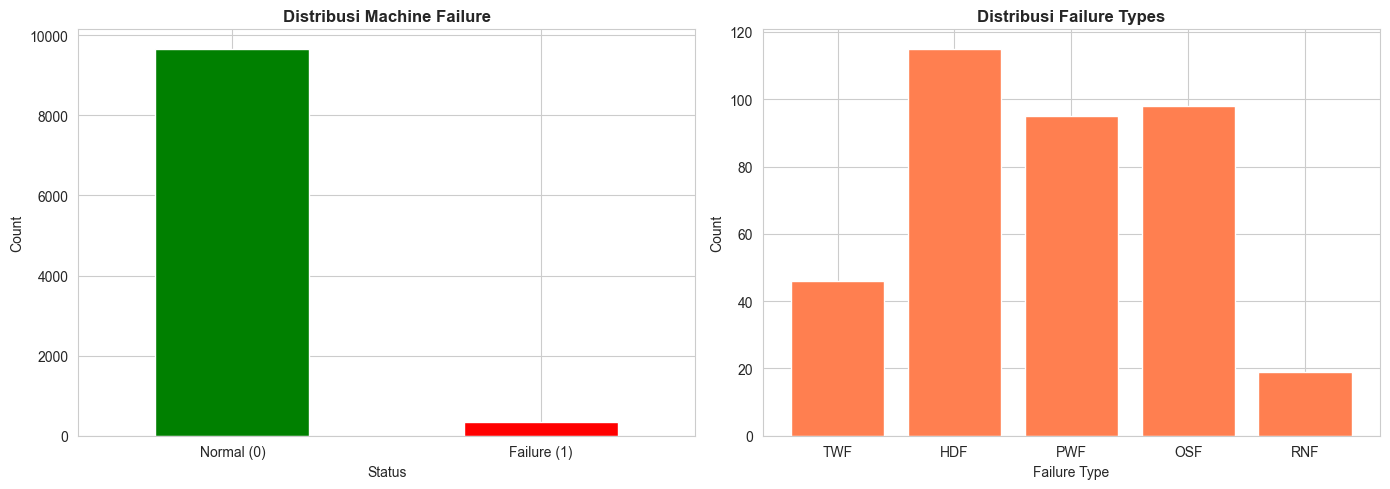

In [11]:
# Plot distribusi Machine Failure
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Machine Failure
df['Machine failure'].value_counts().plot(kind='bar', ax=axes[0], color=['green', 'red'])
axes[0].set_title('Distribusi Machine Failure', fontweight='bold')
axes[0].set_xlabel('Status')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['Normal (0)', 'Failure (1)'], rotation=0)

# Failure Types
failure_counts = [df[ft].sum() for ft in failure_types]
axes[1].bar(failure_types, failure_counts, color='coral')
axes[1].set_title('Distribusi Failure Types', fontweight='bold')
axes[1].set_xlabel('Failure Type')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

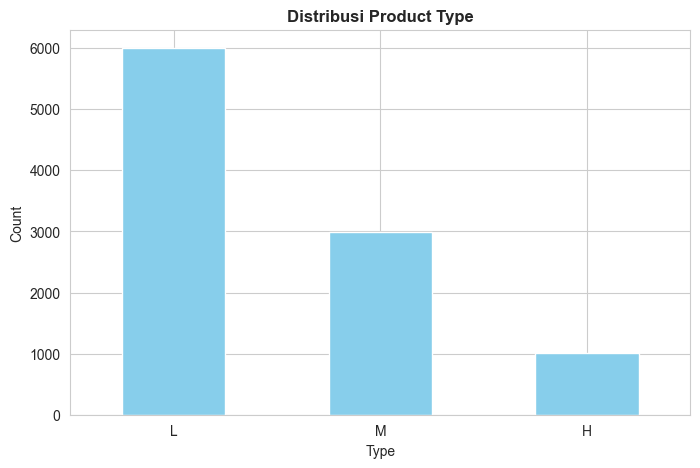

In [12]:
# Plot distribusi Product Type
plt.figure(figsize=(8, 5))
df['Type'].value_counts().plot(kind='bar', color='skyblue')
plt.title('Distribusi Product Type', fontweight='bold')
plt.xlabel('Type')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

### Distribusi Fitur Numerik

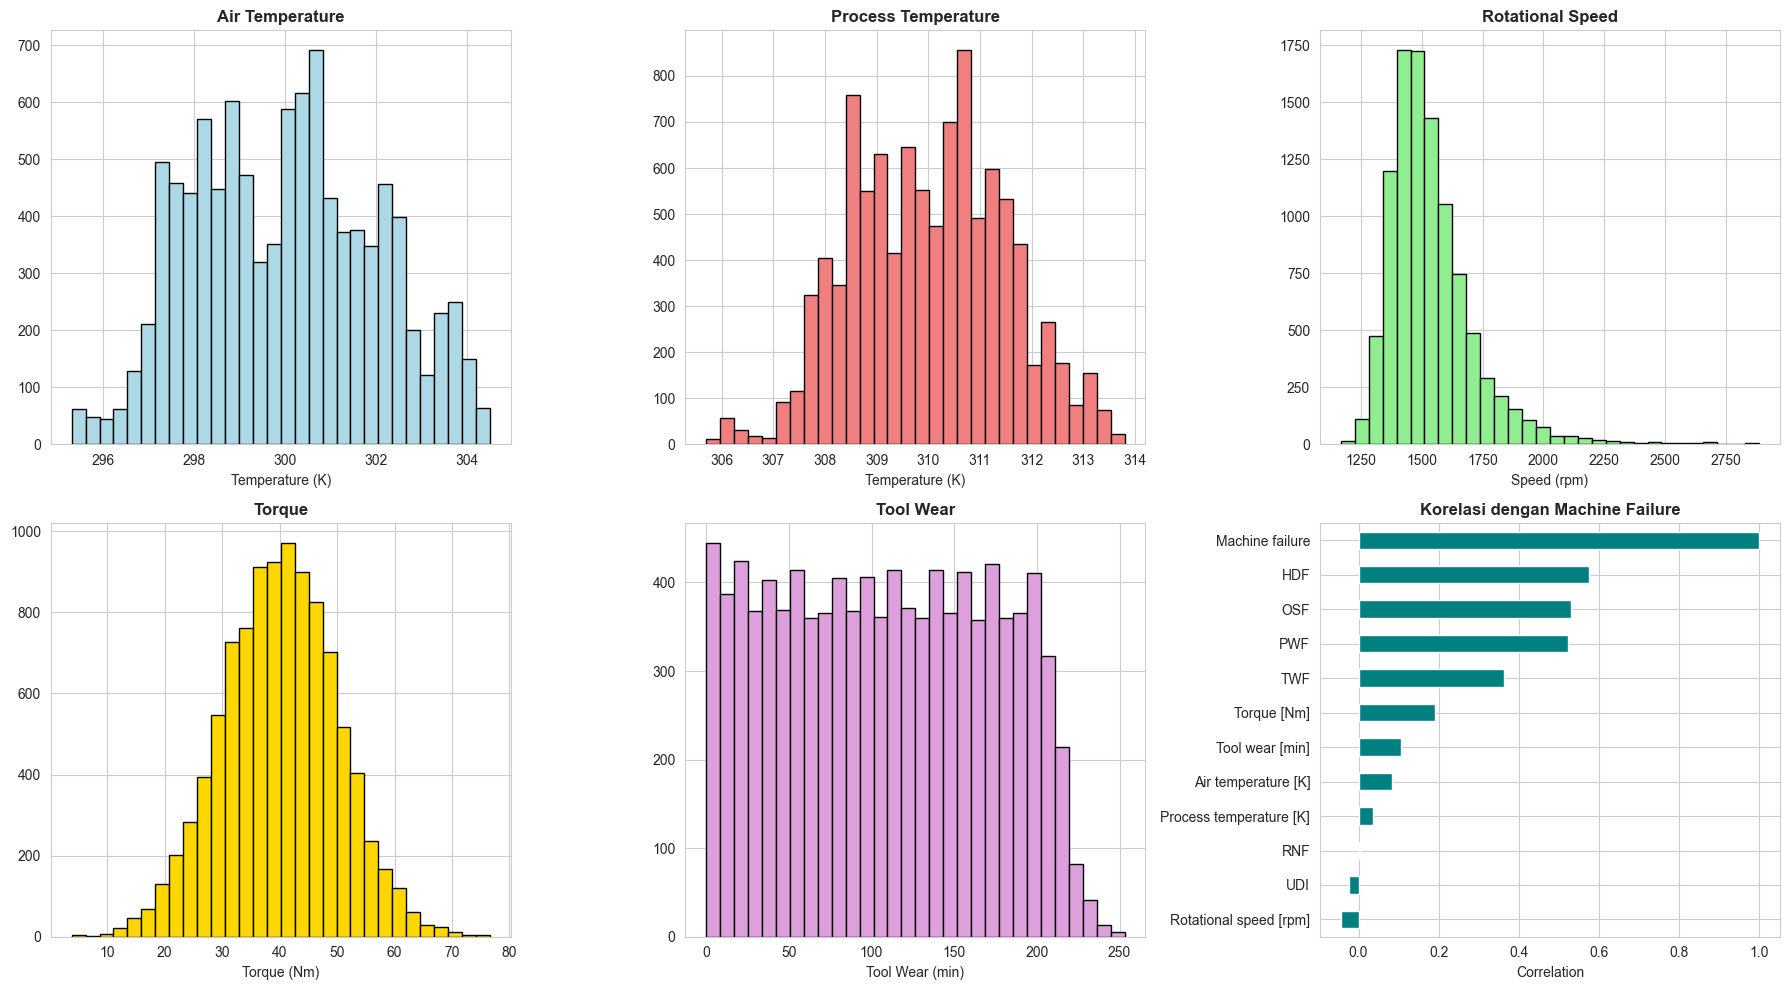

In [13]:
# Plot distribusi fitur numerik
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Air Temperature
axes[0, 0].hist(df['Air temperature [K]'], bins=30, color='lightblue', edgecolor='black')
axes[0, 0].set_title('Air Temperature', fontweight='bold')
axes[0, 0].set_xlabel('Temperature (K)')

# Process Temperature
axes[0, 1].hist(df['Process temperature [K]'], bins=30, color='lightcoral', edgecolor='black')
axes[0, 1].set_title('Process Temperature', fontweight='bold')
axes[0, 1].set_xlabel('Temperature (K)')

# Rotational Speed
axes[0, 2].hist(df['Rotational speed [rpm]'], bins=30, color='lightgreen', edgecolor='black')
axes[0, 2].set_title('Rotational Speed', fontweight='bold')
axes[0, 2].set_xlabel('Speed (rpm)')

# Torque
axes[1, 0].hist(df['Torque [Nm]'], bins=30, color='gold', edgecolor='black')
axes[1, 0].set_title('Torque', fontweight='bold')
axes[1, 0].set_xlabel('Torque (Nm)')

# Tool Wear
axes[1, 1].hist(df['Tool wear [min]'], bins=30, color='plum', edgecolor='black')
axes[1, 1].set_title('Tool Wear', fontweight='bold')
axes[1, 1].set_xlabel('Tool Wear (min)')

# Correlation with Machine Failure
numeric_cols = df.select_dtypes(include=[np.number]).columns
correlations = df[numeric_cols].corrwith(df['Machine failure']).sort_values(ascending=True)
correlations.plot(kind='barh', ax=axes[1, 2], color='teal')
axes[1, 2].set_title('Korelasi dengan Machine Failure', fontweight='bold')
axes[1, 2].set_xlabel('Correlation')

plt.tight_layout()
plt.show()

### Correlation Heatmap

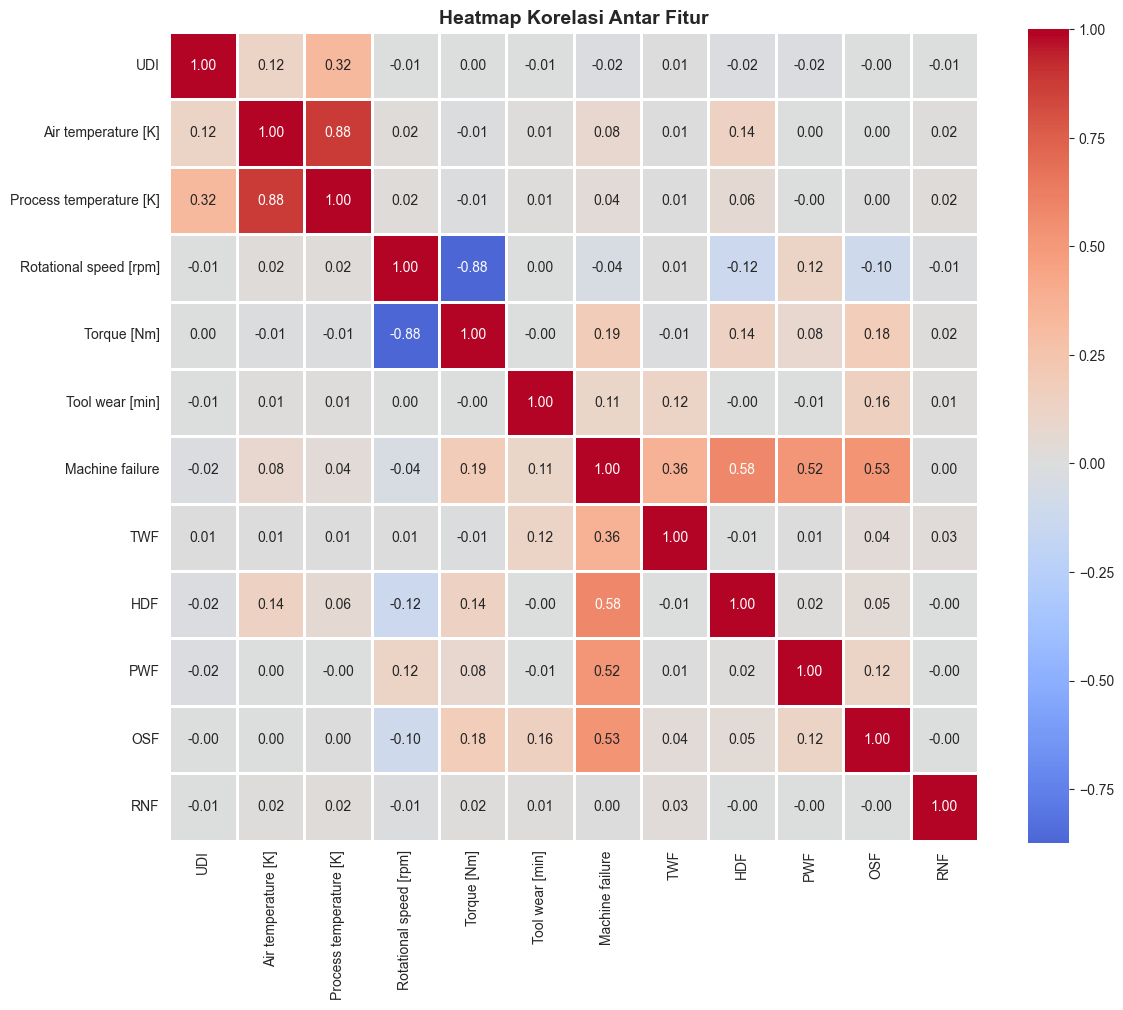

In [14]:
# Heatmap korelasi
plt.figure(figsize=(12, 10))
numeric_df = df.select_dtypes(include=[np.number])
correlation_matrix = numeric_df.corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=1)
plt.title('Heatmap Korelasi Antar Fitur', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Data Preprocessing

### 4.1 Drop Unnecessary Columns

In [15]:
# Copy dataframe
df_processed = df.copy()

# Drop kolom tidak penting
columns_to_drop = ['UDI', 'Product ID']
df_processed = df_processed.drop(columns=columns_to_drop)

print(f"Kolom dihapus: {columns_to_drop}")
print(f"Shape setelah drop: {df_processed.shape}")

Kolom dihapus: ['UDI', 'Product ID']
Shape setelah drop: (10000, 12)


### 4.2 Encode Categorical Features

In [16]:
# Encode kolom Type (L, M, H)
label_encoder = LabelEncoder()
df_processed['Type'] = label_encoder.fit_transform(df_processed['Type'])

print("Encoding Type:")
print(dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))
print(f"\nType setelah encoding:")
print(df_processed['Type'].value_counts())

Encoding Type:
{'H': 0, 'L': 1, 'M': 2}

Type setelah encoding:
Type
1    6000
2    2997
0    1003
Name: count, dtype: int64


### 4.3 Separate Features and Target

In [17]:
# Fitur untuk model
feature_cols = ['Type', 'Air temperature [K]', 'Process temperature [K]',
                'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']

X = df_processed[feature_cols]
y = df_processed['Machine failure']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeature columns: {list(X.columns)}")

Features shape: (10000, 6)
Target shape: (10000,)

Feature columns: ['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']


### 4.4 Feature Scaling

In [18]:
# Normalisasi menggunakan StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("Fitur berhasil dinormalisasi")
print(f"\nStatistik setelah scaling:")
print(X_scaled.describe())

Fitur berhasil dinormalisasi

Statistik setelah scaling:
               Type  Air temperature [K]  Process temperature [K]  \
count  1.000000e+04         1.000000e+04             1.000000e+04   
mean  -3.765876e-17        -9.322321e-16            -1.693934e-15   
std    1.000050e+00         1.000050e+00             1.000050e+00   
min   -1.998335e+00        -2.352278e+00            -2.901986e+00   
25%   -3.322228e-01        -8.523974e-01            -8.125581e-01   
50%   -3.322228e-01         4.753123e-02             6.365340e-02   
75%    1.333889e+00         7.474757e-01             7.376623e-01   
max    1.333889e+00         2.247357e+00             2.557486e+00   

       Rotational speed [rpm]   Torque [Nm]  Tool wear [min]  
count            1.000000e+04  1.000000e+04     1.000000e+04  
mean            -2.330580e-16  5.424994e-16     1.051603e-16  
std              1.000050e+00  1.000050e+00     1.000050e+00  
min             -2.068196e+00 -3.630149e+00    -1.695984e+00  
25%   

In [19]:
# Tambahkan target kembali
df_processed_scaled = X_scaled.copy()
df_processed_scaled['Machine failure'] = df_processed['Machine failure'].values
df_processed_scaled['TWF'] = df_processed['TWF'].values
df_processed_scaled['HDF'] = df_processed['HDF'].values
df_processed_scaled['PWF'] = df_processed['PWF'].values
df_processed_scaled['OSF'] = df_processed['OSF'].values
df_processed_scaled['RNF'] = df_processed['RNF'].values

print(f"Shape akhir: {df_processed_scaled.shape}")
df_processed_scaled.head()

Shape akhir: (10000, 12)


,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1.333889,-0.952389,-0.947360,0.068185,0.282200,-1.695984,0,0,0,0,0,0
1,-0.332223,-0.902393,-0.879959,-0.729472,0.633308,-1.648852,0,0,0,0,0,0
2,-0.332223,-0.952389,-1.014761,-0.227450,0.944290,-1.617430,0,0,0,0,0,0
3,-0.332223,-0.902393,-0.947360,-0.590021,-0.048845,-1.586009,0,0,0,0,0,0
4,-0.332223,-0.902393,-0.879959,-0.729472,0.001313,-1.554588,0,0,0,0,0,0


## 5. Train-Test Split

In [20]:
# Split data dengan stratified
X = df_processed_scaled[feature_cols]
y = df_processed_scaled['Machine failure']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"\nDistribusi target di training set:")
print(f"Normal (0): {(y_train == 0).sum()} ({(y_train == 0).sum()/len(y_train)*100:.2f}%)")
print(f"Failure (1): {(y_train == 1).sum()} ({(y_train == 1).sum()/len(y_train)*100:.2f}%)")

Training set: 8000 samples
Test set: 2000 samples

Distribusi target di training set:
Normal (0): 7729 (96.61%)
Failure (1): 271 (3.39%)


## 6. Handle Imbalanced Data with SMOTE

Distribusi sebelum SMOTE:
Normal (0): 7729 (96.61%)
Failure (1): 271 (3.39%)


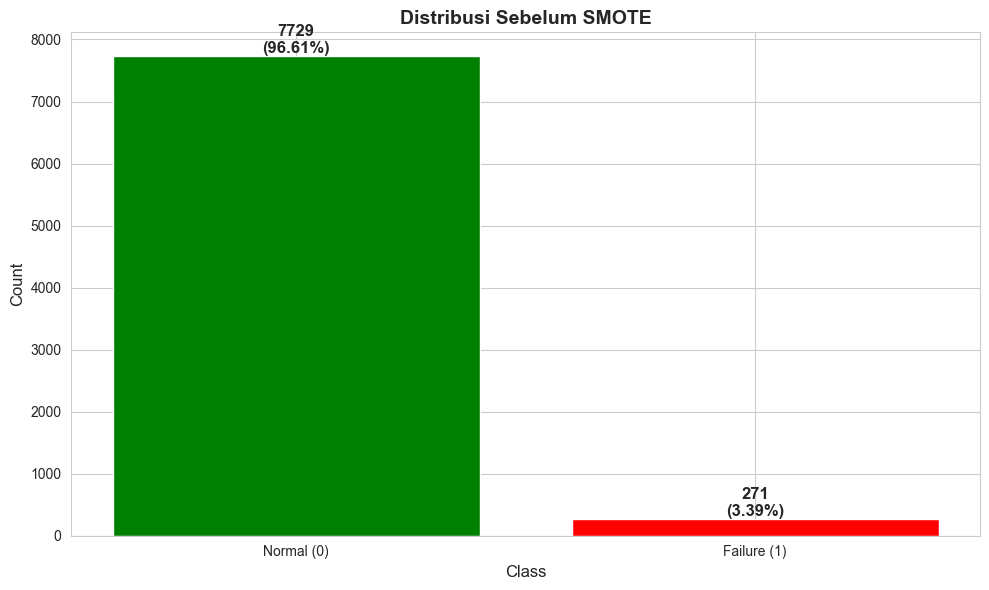

In [21]:
# Visualisasi sebelum SMOTE
count_0_before = (y_train == 0).sum()
count_1_before = (y_train == 1).sum()

print(f"Distribusi sebelum SMOTE:")
print(f"Normal (0): {count_0_before} ({count_0_before/len(y_train)*100:.2f}%)")
print(f"Failure (1): {count_1_before} ({count_1_before/len(y_train)*100:.2f}%)")

plt.figure(figsize=(10, 6))
bars = plt.bar(['Normal (0)', 'Failure (1)'], [count_0_before, count_1_before], color=['green', 'red'])
plt.title('Distribusi Sebelum SMOTE', fontweight='bold', fontsize=14)
plt.xlabel('Class', fontsize=12)
plt.ylabel('Count', fontsize=12)

# Tambahkan angka di atas bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}\n({height/len(y_train)*100:.2f}%)',
             ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

In [22]:
# Apply SMOTE
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

count_0_after = (y_train_resampled == 0).sum()
count_1_after = (y_train_resampled == 1).sum()

print(f"Distribusi setelah SMOTE:")
print(f"Normal (0): {count_0_after} ({count_0_after/len(y_train_resampled)*100:.2f}%)")
print(f"Failure (1): {count_1_after} ({count_1_after/len(y_train_resampled)*100:.2f}%)")
print(f"\nShape sebelum: {X_train.shape}")
print(f"Shape setelah: {X_train_resampled.shape}")
print(f"\nPeningkatan data:")
print(f"Normal (0): +{count_0_after - count_0_before} samples")
print(f"Failure (1): +{count_1_after - count_1_before} samples")

Distribusi setelah SMOTE:
Normal (0): 7729 (50.00%)
Failure (1): 7729 (50.00%)

Shape sebelum: (8000, 6)
Shape setelah: (15458, 6)

Peningkatan data:
Normal (0): +0 samples
Failure (1): +7458 samples


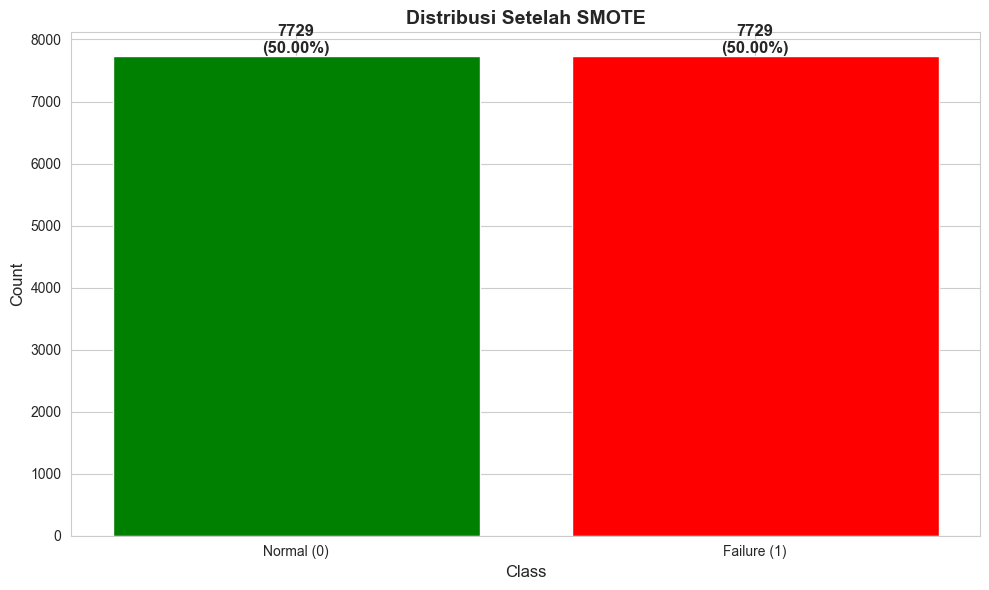

In [23]:
# Visualisasi setelah SMOTE
plt.figure(figsize=(10, 6))
bars = plt.bar(['Normal (0)', 'Failure (1)'], [count_0_after, count_1_after], color=['green', 'red'])
plt.title('Distribusi Setelah SMOTE', fontweight='bold', fontsize=14)
plt.xlabel('Class', fontsize=12)
plt.ylabel('Count', fontsize=12)

# Tambahkan angka di atas bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}\n({height/len(y_train_resampled)*100:.2f}%)',
             ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

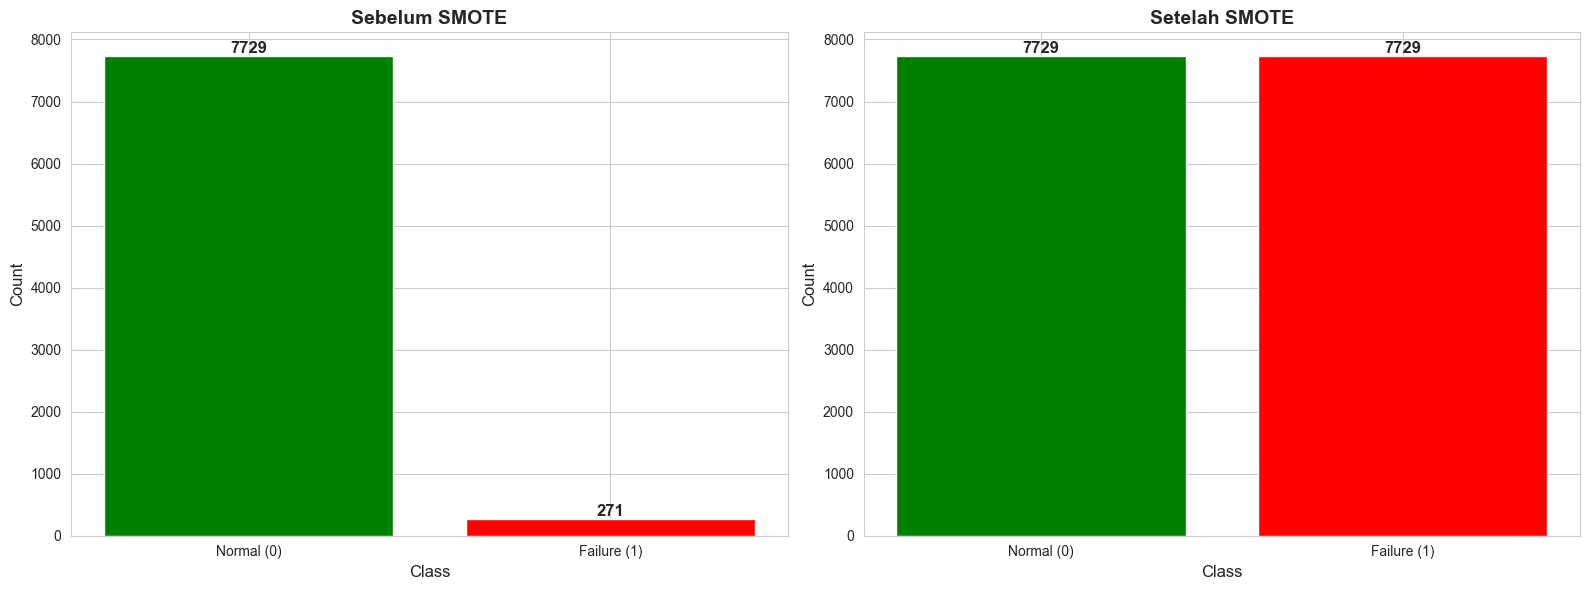

In [24]:
# Perbandingan Before vs After SMOTE
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Before SMOTE
bars1 = axes[0].bar(['Normal (0)', 'Failure (1)'], [count_0_before, count_1_before], color=['green', 'red'])
axes[0].set_title('Sebelum SMOTE', fontweight='bold', fontsize=14)
axes[0].set_xlabel('Class', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
for bar in bars1:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                 f'{int(height)}',
                 ha='center', va='bottom', fontsize=12, fontweight='bold')

# After SMOTE
bars2 = axes[1].bar(['Normal (0)', 'Failure (1)'], [count_0_after, count_1_after], color=['green', 'red'])
axes[1].set_title('Setelah SMOTE', fontweight='bold', fontsize=14)
axes[1].set_xlabel('Class', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)
for bar in bars2:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                 f'{int(height)}',
                 ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

In [25]:
print("X_train asli:", X_train.shape)
print("y_train asli:", y_train.shape)

print("X_train SMOTE:", X_train_resampled.shape)
print("y_train SMOTE:", y_train_resampled.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train asli: (8000, 6)
y_train asli: (8000,)
X_train SMOTE: (15458, 6)
y_train SMOTE: (15458,)
X_test: (2000, 6)
y_test: (2000,)


In [26]:
print("Distribusi y_train asli:")
print(y_train.value_counts())

print("\nDistribusi y_train setelah SMOTE:")
print(pd.Series(y_train_resampled).value_counts())

print("\nDistribusi y_test:")
print(y_test.value_counts())

Distribusi y_train asli:
Machine failure
0    7729
1     271
Name: count, dtype: int64

Distribusi y_train setelah SMOTE:
Machine failure
0    7729
1    7729
Name: count, dtype: int64

Distribusi y_test:
Machine failure
0    1932
1      68
Name: count, dtype: int64


## 7. Baseline Model

In [27]:
# ============================================================
# BASELINE MODEL - RANDOM FOREST BINARY CLASSIFICATION
# Sebelum Hyperparameter Tuning
# ============================================================

print("Baseline Model - Random Forest Binary")
print("=" * 50)

rf_binary_baseline = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

# Train baseline model pakai data hasil SMOTE
rf_binary_baseline.fit(X_train_resampled, y_train_resampled)

# Prediksi pada test set asli
y_pred_baseline = rf_binary_baseline.predict(X_test)
y_prob_baseline = rf_binary_baseline.predict_proba(X_test)[:, 1]

# Evaluasi baseline
baseline_accuracy = accuracy_score(y_test, y_pred_baseline)
baseline_recall = recall_score(y_test, y_pred_baseline, pos_label=1, zero_division=0)
baseline_precision = precision_score(y_test, y_pred_baseline, pos_label=1, zero_division=0)
baseline_f1 = f1_score(y_test, y_pred_baseline, pos_label=1, zero_division=0)
baseline_auc = roc_auc_score(y_test, y_prob_baseline)

print(f"Accuracy          : {baseline_accuracy:.4f}")
print(f"Recall Failure    : {baseline_recall:.4f}")
print(f"Precision Failure : {baseline_precision:.4f}")
print(f"F1-Score Failure  : {baseline_f1:.4f}")
print(f"ROC-AUC           : {baseline_auc:.4f}")

print("\nClassification Report Baseline:")
print(classification_report(y_test, y_pred_baseline, target_names=["Normal", "Failure"], zero_division=0))

Baseline Model - Random Forest Binary
Accuracy          : 0.9720
Recall Failure    : 0.7941
Precision Failure : 0.5625
F1-Score Failure  : 0.6585
ROC-AUC           : 0.9764

Classification Report Baseline:
              precision    recall  f1-score   support

      Normal       0.99      0.98      0.99      1932
     Failure       0.56      0.79      0.66        68

    accuracy                           0.97      2000
   macro avg       0.78      0.89      0.82      2000
weighted avg       0.98      0.97      0.97      2000



In [28]:
# ============================================================
# MLFLOW LOGGING - BASELINE MODEL
# ============================================================

with mlflow.start_run(run_name="Baseline_RandomForest_Binary"):
    mlflow.log_param("model", "RandomForestClassifier")
    mlflow.log_param("n_estimators", 100)
    mlflow.log_param("class_weight", "balanced")
    mlflow.log_param("data_training", "SMOTE")

    mlflow.log_metric("accuracy", baseline_accuracy)
    mlflow.log_metric("recall_failure", baseline_recall)
    mlflow.log_metric("precision_failure", baseline_precision)
    mlflow.log_metric("f1_failure", baseline_f1)
    mlflow.log_metric("roc_auc", baseline_auc)

    mlflow.sklearn.log_model(rf_binary_baseline, "baseline_binary_model")

    print("Baseline model berhasil dicatat ke MLflow.")

2026/04/27 14:01:27 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/27 14:01:27 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Baseline model berhasil dicatat ke MLflow.


## 8. Prepare Multiclass Data

In [29]:
# ============================================================
# PREPARE MULTICLASS DATA
# ============================================================

failure_types_list = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
all_class_labels   = list(range(len(failure_types_list)))

failure_indices = y_train[y_train == 1].index
y_train_multi   = []
valid_indices   = []

for idx in failure_indices:
    for i, ft in enumerate(failure_types_list):
        if df_processed_scaled.loc[idx, ft] == 1:
            y_train_multi.append(i)
            valid_indices.append(idx)
            break

X_train_multi      = X_train.loc[valid_indices]
y_train_multi_series = pd.Series(y_train_multi, index=valid_indices)

print(f"Jumlah failure cases training: {len(X_train_multi)}")
print(f"\nDistribusi failure types:")
for i, ft in enumerate(failure_types_list):
    count = (y_train_multi_series == i).sum()
    print(f"  {ft} ({i}): {count} ({count/len(y_train_multi_series)*100:.2f}%)")

Jumlah failure cases training: 264

Distribusi failure types:
  TWF (0): 36 (13.64%)
  HDF (1): 86 (32.58%)
  PWF (2): 79 (29.92%)
  OSF (3): 63 (23.86%)
  RNF (4): 0 (0.00%)


In [30]:
# Siapkan juga test set multiclass
test_failure_idx  = y_test[y_test == 1].index
y_test_multi      = []
valid_test_indices = []

for idx in test_failure_idx:
    for i, ft in enumerate(failure_types_list):
        if df_processed_scaled.loc[idx, ft] == 1:
            y_test_multi.append(i)
            valid_test_indices.append(idx)
            break

X_test_multi       = X_test.loc[valid_test_indices]
y_test_multi_series = pd.Series(y_test_multi, index=valid_test_indices)

print(f"Jumlah failure cases test: {len(X_test_multi)}")

Jumlah failure cases test: 66


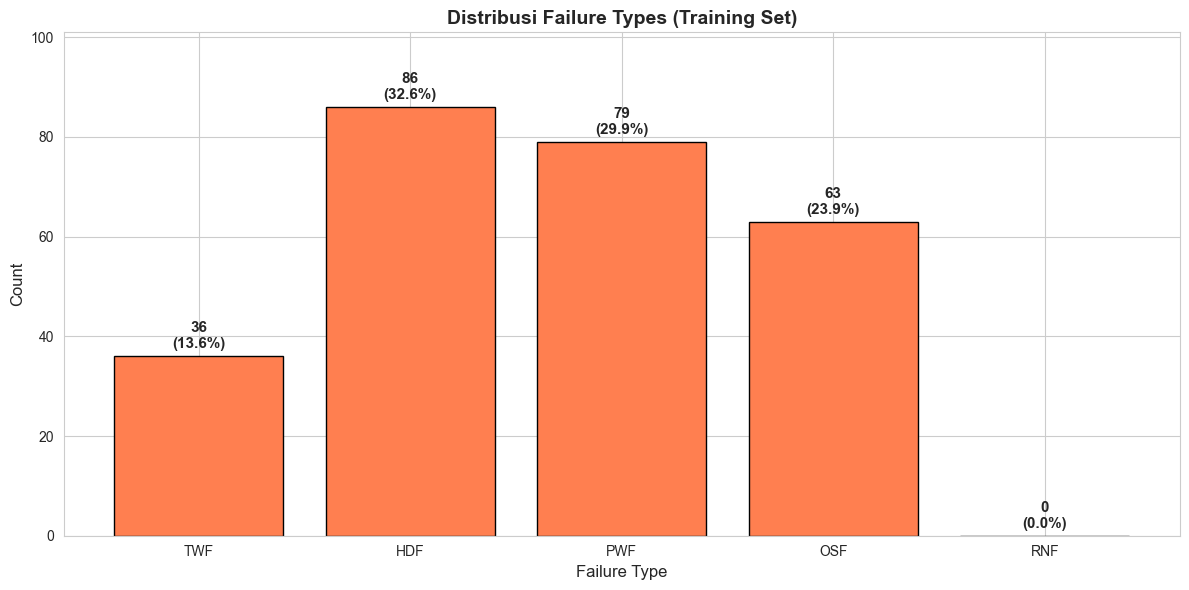

In [31]:
# ============================================================
# VISUALISASI DISTRIBUSI FAILURE TYPES - TRAINING SET
# ============================================================

plt.figure(figsize=(12, 6))

failure_type_counts = []

for i in range(len(failure_types_list)):
    count = (y_train_multi_series == i).sum()
    failure_type_counts.append(count)

bars = plt.bar(
    failure_types_list,
    failure_type_counts,
    color='coral',
    edgecolor='black'
)

plt.title(
    'Distribusi Failure Types (Training Set)',
    fontweight='bold',
    fontsize=14
)

plt.xlabel('Failure Type', fontsize=12)
plt.ylabel('Count', fontsize=12)

# Tambahkan angka dan persentase di atas bar
total_failure = len(y_train_multi_series)

for bar, count in zip(bars, failure_type_counts):
    height = bar.get_height()

    percentage = (count / total_failure * 100) if total_failure > 0 else 0

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1,
        f'{int(count)}\n({percentage:.1f}%)',
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

plt.ylim(0, max(failure_type_counts) + 15)
plt.tight_layout()
plt.show()

## 9. OPTUNA BINARY

Optuna Tuning - Binary Classification
Objective: Maximize Recall Failure


  0%|          | 0/50 [00:00<?, ?it/s]


Best Recall Failure (CV) : 0.9909
Best Params:
  n_estimators: 131
  max_depth: 20
  min_samples_split: 2
  min_samples_leaf: 1
  max_features: sqrt
  class_weight: balanced_subsample

Model Binary Tuned selesai dilatih!

Feature Importance:
Torque [Nm]                0.321725
Rotational speed [rpm]     0.275791
Tool wear [min]            0.211045
Air temperature [K]        0.101648
Process temperature [K]    0.062449
Type                       0.027341
dtype: float64


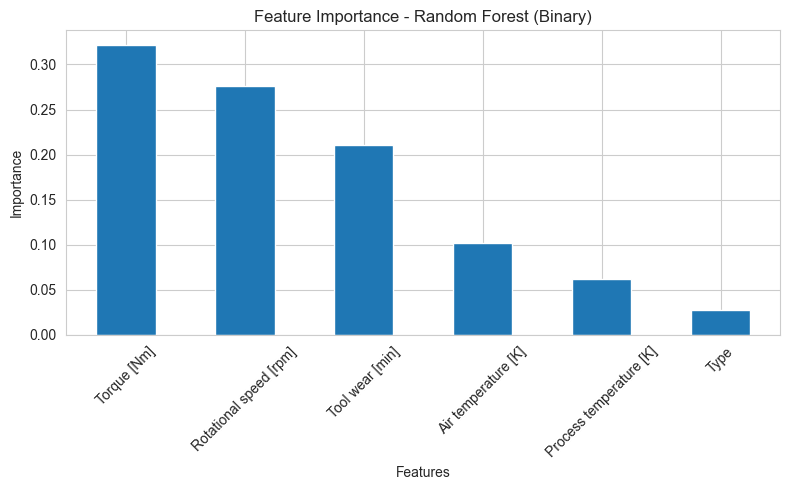

2026/04/27 14:03:18 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/27 14:03:18 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Binary model dan feature importance berhasil dicatat ke MLflow.


In [32]:
# ============================================================
# OPTUNA TUNING - BINARY CLASSIFICATION
# Objective: Maximize Recall Failure
# ============================================================

print("Optuna Tuning - Binary Classification")
print("Objective: Maximize Recall Failure")
print("=" * 50)

def objective_binary(trial):
    params = {
        'n_estimators'     : trial.suggest_int('n_estimators', 50, 300),
        'max_depth'        : trial.suggest_int('max_depth', 3, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf' : trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features'     : trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        'class_weight'     : trial.suggest_categorical('class_weight', ['balanced', 'balanced_subsample']),
        'random_state'     : 42,
        'n_jobs'           : -1
    }

    model = RandomForestClassifier(**params)
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

    y_pred = cross_val_predict(
        model,
        X_train_resampled,
        y_train_resampled,
        cv=cv
    )

    return recall_score(y_train_resampled, y_pred, pos_label=1)


study_binary = optuna.create_study(
    direction='maximize',
    study_name='binary_recall'
)

study_binary.optimize(
    objective_binary,
    n_trials=50,
    show_progress_bar=True
)

print(f"\nBest Recall Failure (CV) : {study_binary.best_value:.4f}")
print("Best Params:")

for k, v in study_binary.best_params.items():
    print(f"  {k}: {v}")


# ============================================================
# TRAIN ULANG DENGAN BEST PARAMS
# ============================================================

best_params_binary = study_binary.best_params.copy()
best_params_binary['random_state'] = 42
best_params_binary['n_jobs'] = -1

rf_binary_tuned = RandomForestClassifier(**best_params_binary)
rf_binary_tuned.fit(X_train_resampled, y_train_resampled)

print("\nModel Binary Tuned selesai dilatih!")


# ============================================================
# FEATURE IMPORTANCE
# ============================================================

feature_cols = [
    'Type',
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]'
]

importance = pd.Series(
    rf_binary_tuned.feature_importances_,
    index=feature_cols
).sort_values(ascending=False)

print("\nFeature Importance:")
print(importance)

importance_df = importance.reset_index()
importance_df.columns = ['feature', 'importance']

importance_path = "feature_importance_binary.csv"
importance_df.to_csv(importance_path, index=False)


# Plot feature importance
plt.figure(figsize=(8, 5))
importance.plot(kind='bar')
plt.title("Feature Importance - Random Forest (Binary)")
plt.ylabel("Importance")
plt.xlabel("Features")
plt.xticks(rotation=45)
plt.tight_layout()

importance_plot_path = "feature_importance_binary.png"
plt.savefig(importance_plot_path, dpi=300, bbox_inches="tight")

plt.show()


# ============================================================
# MLFLOW LOGGING - BINARY MODEL + FEATURE IMPORTANCE
# ============================================================

with mlflow.start_run(run_name="Binary_RandomForest_Optuna"):
    mlflow.log_params(best_params_binary)
    mlflow.log_metric("best_recall_failure_cv", study_binary.best_value)

    mlflow.log_artifact(importance_path)
    mlflow.log_artifact(importance_plot_path)

    mlflow.sklearn.log_model(
        rf_binary_tuned,
        "binary_random_forest_model"
    )

    print("Binary model dan feature importance berhasil dicatat ke MLflow.")

## 10. OPTUNA MULTICLASS

In [33]:
# ============================================================
# OPTUNA TUNING - MULTICLASS CLASSIFICATION
# Objective: Maximize F1-Macro
# ============================================================

print("Optuna Tuning - Multiclass Classification")
print("Objective: Maximize F1-Macro")
print("=" * 50)

def objective_multiclass(trial):
    params = {
        'n_estimators'     : trial.suggest_int('n_estimators', 50, 300),
        'max_depth'        : trial.suggest_int('max_depth', 3, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf' : trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features'     : trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        'class_weight'     : trial.suggest_categorical('class_weight', ['balanced', 'balanced_subsample']),
        'random_state'     : 42,
        'n_jobs'           : -1
    }

    model  = RandomForestClassifier(**params)
    cv     = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    y_pred = cross_val_predict(model, X_train_multi, y_train_multi_series, cv=cv)

    return f1_score(y_train_multi_series, y_pred, average='macro', zero_division=0)

study_multiclass = optuna.create_study(direction='maximize', study_name='multiclass_f1macro')
study_multiclass.optimize(objective_multiclass, n_trials=50, show_progress_bar=True)

print(f"\nBest F1-Macro (CV) : {study_multiclass.best_value:.4f}")
print(f"Best Params:")
for k, v in study_multiclass.best_params.items():
    print(f"  {k}: {v}")

best_params_multi                = study_multiclass.best_params.copy()
best_params_multi['random_state'] = 42
best_params_multi['n_jobs']       = -1

rf_multiclass_tuned = RandomForestClassifier(**best_params_multi)
rf_multiclass_tuned.fit(X_train_multi, y_train_multi_series)

# ==============================================================
# MLFlow
# ==============================================================

with mlflow.start_run(run_name="Multiclass_Model_Optuna"):

    mlflow.log_params(best_params_multi)
    mlflow.log_metric("best_f1_macro_cv", study_multiclass.best_value)

    mlflow.sklearn.log_model(rf_multiclass_tuned, "multiclass_model")

    print("MLflow Multiclass logged")

print("\nModel Multiclass Tuned selesai dilatih!")

Optuna Tuning - Multiclass Classification
Objective: Maximize F1-Macro


  0%|          | 0/50 [00:00<?, ?it/s]


Best F1-Macro (CV) : 0.8821
Best Params:
  n_estimators: 190
  max_depth: 9
  min_samples_split: 7
  min_samples_leaf: 1
  max_features: sqrt
  class_weight: balanced_subsample


2026/04/27 14:04:44 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/27 14:04:44 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


MLflow Multiclass logged

Model Multiclass Tuned selesai dilatih!


## 11. THRESHOLD TUNING

Mencari Threshold Optimal...
Threshold Optimal : 0.76
Recall Failure    : 0.6471
Precision Failure : 0.7857
F1-Score Failure  : 0.7097


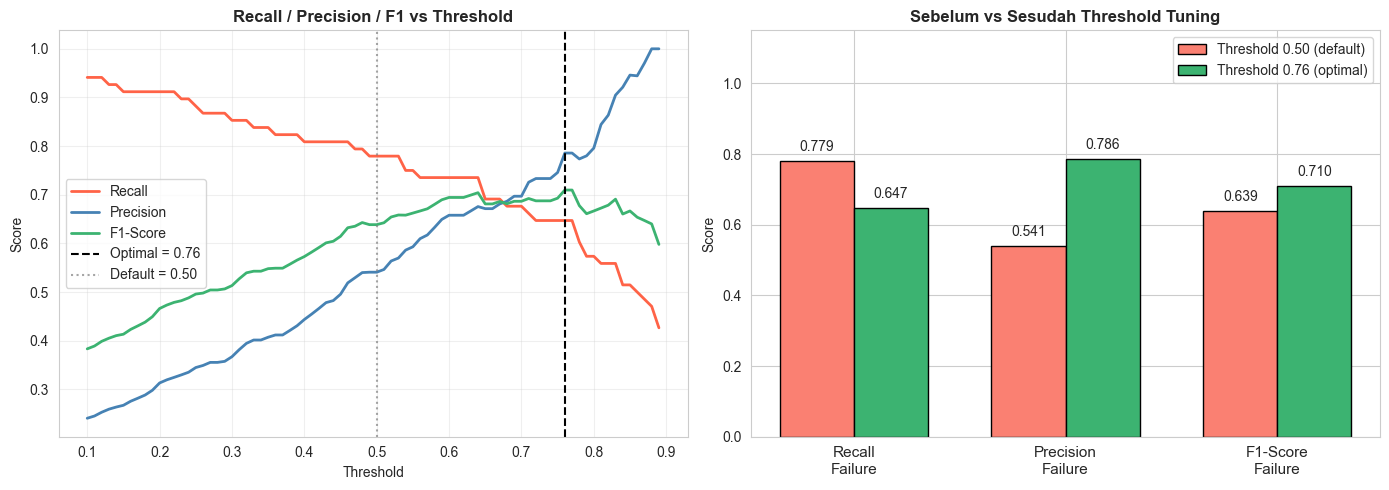

Threshold tuning berhasil dicatat ke MLflow.

Prediksi final menggunakan threshold = 0.76


In [ ]:
# ============================================================
# THRESHOLD TUNING - PRIORITAS RECALL FAILURE
# Cari threshold optimal untuk menaikkan Recall Failure
# dengan batas minimum Precision agar false positive tidak terlalu tinggi
# ============================================================

print("Mencari Threshold Optimal untuk Recall Failure...")
print("=" * 60)

y_prob_tuned = rf_binary_tuned.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.1, 0.9, 0.01)
recalls, precisions, f1_scores = [], [], []

for thresh in thresholds:
    y_pred_t = (y_prob_tuned >= thresh).astype(int)

    recalls.append(
        recall_score(y_test, y_pred_t, pos_label=1, zero_division=0)
    )
    precisions.append(
        precision_score(y_test, y_pred_t, pos_label=1, zero_division=0)
    )
    f1_scores.append(
        f1_score(y_test, y_pred_t, pos_label=1, zero_division=0)
    )

recalls = np.array(recalls)
precisions = np.array(precisions)
f1_scores = np.array(f1_scores)


# ============================================================
# STRATEGI PEMILIHAN THRESHOLD
# ============================================================
# Fokus utama: Recall Failure setinggi mungkin
# Syarat: Precision minimal tetap dijaga
# Kamu bisa ubah nilai ini:
# - 0.60 = lebih seimbang
# - 0.50 = recall lebih tinggi, false positive lebih banyak
# - 0.70 = lebih ketat, precision tinggi tapi recall bisa turun
# ============================================================

min_precision = 0.60

valid_idx = np.where(precisions >= min_precision)[0]

if len(valid_idx) > 0:
    best_idx = valid_idx[np.argmax(recalls[valid_idx])]
    selection_strategy = f"Max Recall with Precision >= {min_precision}"
else:
    best_idx = np.argmax(f1_scores)
    selection_strategy = "Fallback to Max F1-Score"

best_threshold = thresholds[best_idx]
best_recall = recalls[best_idx]
best_precision = precisions[best_idx]
best_f1 = f1_scores[best_idx]


print(f"Strategi Threshold : {selection_strategy}")
print(f"Threshold Optimal  : {best_threshold:.2f}")
print(f"Recall Failure     : {best_recall:.4f}")
print(f"Precision Failure  : {best_precision:.4f}")
print(f"F1-Score Failure   : {best_f1:.4f}")


# ============================================================
# PERBANDINGAN DEFAULT VS OPTIMAL
# ============================================================

y_pred_default = (y_prob_tuned >= 0.50).astype(int)
y_pred_optimal = (y_prob_tuned >= best_threshold).astype(int)

scores_def = [
    recall_score(y_test, y_pred_default, pos_label=1, zero_division=0),
    precision_score(y_test, y_pred_default, pos_label=1, zero_division=0),
    f1_score(y_test, y_pred_default, pos_label=1, zero_division=0)
]

scores_opt = [
    best_recall,
    best_precision,
    best_f1
]

print("\nPerbandingan Threshold:")
print(f"Default 0.50 -> Recall: {scores_def[0]:.4f}, Precision: {scores_def[1]:.4f}, F1: {scores_def[2]:.4f}")
print(f"Optimal {best_threshold:.2f} -> Recall: {scores_opt[0]:.4f}, Precision: {scores_opt[1]:.4f}, F1: {scores_opt[2]:.4f}")


# ============================================================
# VISUALISASI
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(thresholds, recalls, label='Recall', color='tomato', lw=2)
axes[0].plot(thresholds, precisions, label='Precision', color='steelblue', lw=2)
axes[0].plot(thresholds, f1_scores, label='F1-Score', color='mediumseagreen', lw=2)

axes[0].axvline(
    x=best_threshold,
    color='black',
    linestyle='--',
    label=f'Optimal = {best_threshold:.2f}'
)

axes[0].axvline(
    x=0.50,
    color='gray',
    linestyle=':',
    label='Default = 0.50',
    alpha=0.7
)

axes[0].set_title(
    'Recall / Precision / F1 vs Threshold',
    fontsize=12,
    fontweight='bold'
)
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('Score')
axes[0].legend()
axes[0].grid(True, alpha=0.3)


labels_bar = [
    'Recall\nFailure',
    'Precision\nFailure',
    'F1-Score\nFailure'
]

x = np.arange(len(labels_bar))
width = 0.35

b1 = axes[1].bar(
    x - width / 2,
    scores_def,
    width,
    label='Threshold 0.50 (default)',
    color='salmon',
    edgecolor='black'
)

b2 = axes[1].bar(
    x + width / 2,
    scores_opt,
    width,
    label=f'Threshold {best_threshold:.2f} (optimal)',
    color='mediumseagreen',
    edgecolor='black'
)

axes[1].set_xticks(x)
axes[1].set_xticklabels(labels_bar, fontsize=11)
axes[1].set_ylim(0, 1.15)
axes[1].set_title(
    'Sebelum vs Sesudah Threshold Tuning',
    fontsize=12,
    fontweight='bold'
)
axes[1].set_ylabel('Score')
axes[1].legend()

for bar in list(b1) + list(b2):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.02,
        f'{bar.get_height():.3f}',
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.tight_layout()

threshold_plot_path = "threshold_tuning_plot.png"
plt.savefig(threshold_plot_path, dpi=300, bbox_inches="tight")

plt.show()


# ============================================================
# MLFLOW LOGGING - THRESHOLD TUNING
# ============================================================

with mlflow.start_run(run_name="Threshold_Tuning"):
    mlflow.log_param("selection_strategy", selection_strategy)
    mlflow.log_param("default_threshold", 0.50)
    mlflow.log_param("best_threshold", float(best_threshold))
    mlflow.log_param("min_precision_constraint", float(min_precision))

    mlflow.log_metric("default_recall_failure", float(scores_def[0]))
    mlflow.log_metric("default_precision_failure", float(scores_def[1]))
    mlflow.log_metric("default_f1_failure", float(scores_def[2]))

    mlflow.log_metric("best_recall_failure", float(best_recall))
    mlflow.log_metric("best_precision_failure", float(best_precision))
    mlflow.log_metric("best_f1_failure", float(best_f1))

    mlflow.log_artifact(threshold_plot_path)

    print("Threshold tuning berhasil dicatat ke MLflow.")


# ============================================================
# SIMPAN PREDIKSI FINAL
# ============================================================

y_pred_final = y_pred_optimal

print(f"\nPrediksi final menggunakan threshold = {best_threshold:.2f}")

## 12. EVALUASI 

       EVALUASI FINAL MODEL FAULTSENSE
       (Optuna + Threshold Tuning)

📌 BINARY CLASSIFICATION
   Accuracy        : 0.9820  (98.20%)
   Recall Failure  : 0.6471  ← deteksi failure
   F1-Score Failure: 0.7097  ← balance precision & recall
   ROC-AUC         : 0.9754  ← kemampuan diskriminasi

📌 MULTICLASS CLASSIFICATION (Jenis Failure)
   F1-Macro        : 0.7103  ← rata-rata per kelas

📌 THRESHOLD YANG DIGUNAKAN: 0.76 (default: 0.50)

--- Classification Report Binary ---
              precision    recall  f1-score   support

      Normal       0.99      0.99      0.99      1932
     Failure       0.79      0.65      0.71        68

    accuracy                           0.98      2000
   macro avg       0.89      0.82      0.85      2000
weighted avg       0.98      0.98      0.98      2000


--- Classification Report Multiclass ---
              precision    recall  f1-score   support

         TWF       1.00      0.70      0.82        10
         HDF       1.00      0.93      0.9

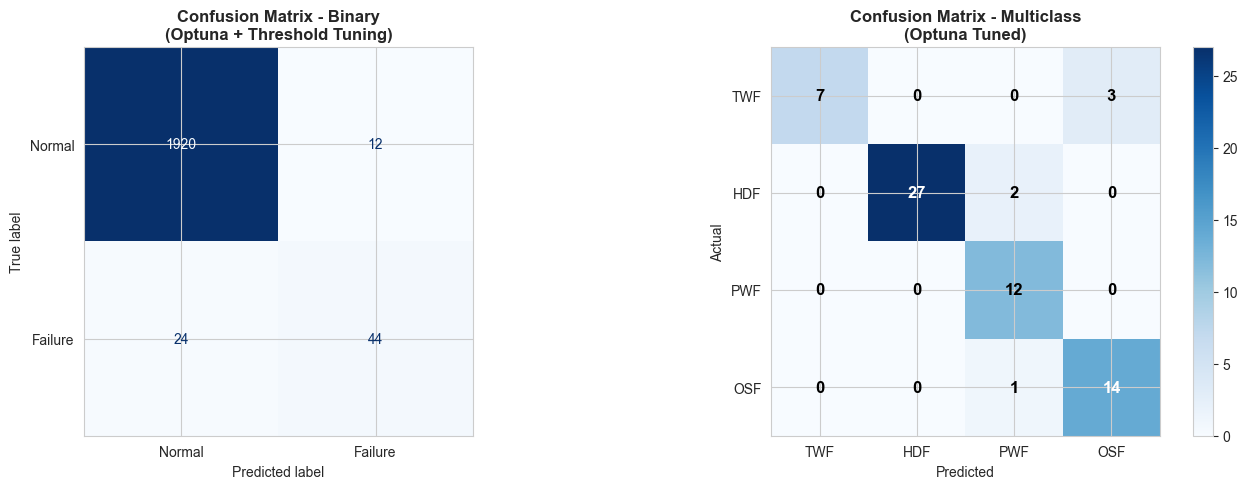

In [35]:
# ============================================================
# EVALUASI FINAL - SEMUA METRIK
# Menggunakan model hasil Optuna + threshold optimal
# ============================================================

y_pred_multi_tuned = rf_multiclass_tuned.predict(X_test_multi)

# Hitung semua metrik
recall_val  = recall_score(y_test, y_pred_final, pos_label=1, zero_division=0)
f1_bin_val  = f1_score(y_test, y_pred_final, pos_label=1, zero_division=0)
auc_val     = roc_auc_score(y_test, y_prob_tuned)
acc_val     = accuracy_score(y_test, y_pred_final)
f1_mac_val  = f1_score(y_test_multi_series, y_pred_multi_tuned,
                        average='macro', labels=all_class_labels, zero_division=0)

print("=" * 60)
print("       EVALUASI FINAL MODEL FAULTSENSE")
print("       (Optuna + Threshold Tuning)")
print("=" * 60)

print(f"\n📌 BINARY CLASSIFICATION")
print(f"   Accuracy        : {acc_val:.4f}  ({acc_val*100:.2f}%)")
print(f"   Recall Failure  : {recall_val:.4f}  ← deteksi failure")
print(f"   F1-Score Failure: {f1_bin_val:.4f}  ← balance precision & recall")
print(f"   ROC-AUC         : {auc_val:.4f}  ← kemampuan diskriminasi")

print(f"\n📌 MULTICLASS CLASSIFICATION (Jenis Failure)")
print(f"   F1-Macro        : {f1_mac_val:.4f}  ← rata-rata per kelas")

print(f"\n📌 THRESHOLD YANG DIGUNAKAN: {best_threshold:.2f} (default: 0.50)")

print(f"\n--- Classification Report Binary ---")
print(classification_report(y_test, y_pred_final,
      target_names=['Normal', 'Failure'], zero_division=0))

print(f"\n--- Classification Report Multiclass ---")
print(classification_report(y_test_multi_series, y_pred_multi_tuned,
      labels=all_class_labels, target_names=failure_types_list, zero_division=0))

# Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_bin = confusion_matrix(y_test, y_pred_final)
ConfusionMatrixDisplay(cm_bin, display_labels=['Normal', 'Failure']).plot(
    ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix - Binary\n(Optuna + Threshold Tuning)',
                  fontsize=12, fontweight='bold')

classes_in_test = sorted(y_test_multi_series.unique())
labels_in_test  = [failure_types_list[i] for i in classes_in_test]
cm_multi = confusion_matrix(y_test_multi_series, y_pred_multi_tuned, labels=classes_in_test)
im = axes[1].imshow(cm_multi, cmap='Blues')
axes[1].set_title('Confusion Matrix - Multiclass\n(Optuna Tuned)',
                  fontsize=12, fontweight='bold')
axes[1].set_xticks(range(len(classes_in_test)))
axes[1].set_yticks(range(len(classes_in_test)))
axes[1].set_xticklabels(labels_in_test)
axes[1].set_yticklabels(labels_in_test)
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
for i in range(len(classes_in_test)):
    for j in range(len(classes_in_test)):
        axes[1].text(j, i, cm_multi[i, j], ha='center', va='center',
                     fontsize=12, fontweight='bold',
                     color='white' if cm_multi[i, j] > cm_multi.max()/2 else 'black')
plt.colorbar(im, ax=axes[1])
plt.tight_layout()
plt.show()

## 13. Save Program

In [ ]:
# ============================================================
# SIMPAN MODEL + THRESHOLD (FIX FINAL)
# ============================================================

import os
import pickle

# gunakan folder production
MODEL_DIR = "models"
os.makedirs(MODEL_DIR, exist_ok=True)

with open(os.path.join(MODEL_DIR, 'model_binary_rf.pkl'), 'wb') as f:
    pickle.dump(rf_binary_tuned, f)

with open(os.path.join(MODEL_DIR, 'model_multiclass_rf.pkl'), 'wb') as f:
    pickle.dump(rf_multiclass_tuned, f)

with open(os.path.join(MODEL_DIR, 'scaler.pkl'), 'wb') as f:
    pickle.dump(scaler, f)

with open(os.path.join(MODEL_DIR, 'label_encoder.pkl'), 'wb') as f:
    pickle.dump(label_encoder, f)

with open(os.path.join(MODEL_DIR, 'threshold.pkl'), 'wb') as f:
    pickle.dump(best_threshold, f)

# ============================================================
# MLFLOW LOGGING
# ============================================================

with mlflow.start_run(run_name="Final_Artifacts"):

    mlflow.log_artifact(os.path.join(MODEL_DIR, "model_binary_rf.pkl"))
    mlflow.log_artifact(os.path.join(MODEL_DIR, "model_multiclass_rf.pkl"))
    mlflow.log_artifact(os.path.join(MODEL_DIR, "scaler.pkl"))
    mlflow.log_artifact(os.path.join(MODEL_DIR, "label_encoder.pkl"))
    mlflow.log_artifact(os.path.join(MODEL_DIR, "threshold.pkl"))

    print("Artifacts berhasil disimpan ke MLflow")

print("Model berhasil disimpan:")
print("  - models/model_binary_rf.pkl")
print("  - models/model_multiclass_rf.pkl")
print("  - models/scaler.pkl")
print("  - models/label_encoder.pkl")
print(f"  - models/threshold.pkl (nilai: {best_threshold:.2f})")

Artifacts berhasil disimpan ke MLflow 
Model berhasil disimpan:
  - model/model_binary_rf.pkl
  - model/model_multiclass_rf.pkl
  - model/scaler.pkl
  - model/label_encoder.pkl
  - model/threshold.pkl  (nilai: 0.76)


## 14. Cascade Prediction

In [37]:
# ============================================================
# CASCADE PREDICTION (pakai threshold optimal)
# ============================================================

def cascade_predict(input_data):
    """
    Prediksi bertahap:
    1. Binary model cek Normal vs Failure (pakai threshold optimal)
    2. Kalau Failure, multiclass model prediksi jenis failure-nya
    """
    prob_failure = rf_binary_tuned.predict_proba(input_data)[0][1]

    if prob_failure < best_threshold:
        return {
            "status"      : "Normal",
            "prob_failure": f"{prob_failure:.4f}",
            "failure_type": None
        }
    else:
        failure_labels     = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
        multiclass_result  = rf_multiclass_tuned.predict(input_data)[0]
        return {
            "status"      : "Failure",
            "prob_failure": f"{prob_failure:.4f}",
            "failure_type": failure_labels[multiclass_result]
        }

# Test dengan 5 sample
print("Contoh prediksi cascade (threshold optimal):\n")
for i in range(5):
    sample = X_test.iloc[[i]]
    hasil  = cascade_predict(sample)
    actual = "Failure" if y_test.iloc[i] == 1 else "Normal"
    print(f"Data ke-{i+1}: Prediksi={hasil} | Aktual={actual}")

Contoh prediksi cascade (threshold optimal):

Data ke-1: Prediksi={'status': 'Normal', 'prob_failure': '0.4733', 'failure_type': None} | Aktual=Normal
Data ke-2: Prediksi={'status': 'Normal', 'prob_failure': '0.0000', 'failure_type': None} | Aktual=Normal
Data ke-3: Prediksi={'status': 'Normal', 'prob_failure': '0.4041', 'failure_type': None} | Aktual=Normal
Data ke-4: Prediksi={'status': 'Normal', 'prob_failure': '0.0076', 'failure_type': None} | Aktual=Normal
Data ke-5: Prediksi={'status': 'Normal', 'prob_failure': '0.1374', 'failure_type': None} | Aktual=Normal


In [38]:
# ============================================================
# TEST CASCADE PREDICTION
# ============================================================

print("=" * 60)
print("TEST CASCADE PREDICTION")
print("=" * 60)

# Pastikan failure label sesuai urutan model multiclass
failure_labels = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']


# ------------------------------------------------------------
# 1. Test beberapa data pertama dari X_test
# ------------------------------------------------------------
print("\n1. Contoh prediksi cascade dari 5 data pertama:\n")

for i in range(5):
    sample = X_test.iloc[[i]]
    hasil = cascade_predict(sample)
    actual = "Failure" if y_test.iloc[i] == 1 else "Normal"

    print(f"Data ke-{i+1}")
    print(f"Prediksi : {hasil}")
    print(f"Aktual   : {actual}")
    print("-" * 40)


# ------------------------------------------------------------
# 2. Test khusus data yang aktualnya Failure
# ------------------------------------------------------------
print("\n2. Contoh prediksi cascade untuk data aktual Failure:\n")

failure_positions = y_test[y_test == 1].index

if len(failure_positions) == 0:
    print("Tidak ada data Failure pada test set.")
else:
    for idx in failure_positions[:5]:
        sample = X_test.loc[[idx]]
        hasil = cascade_predict(sample)
        actual = "Failure"

        # Cari failure type aktual dari kolom TWF/HDF/PWF/OSF/RNF
        actual_failure_type = None

        for ft in failure_labels:
            if df_processed_scaled.loc[idx, ft] == 1:
                actual_failure_type = ft
                break

        print(f"Index data : {idx}")
        print(f"Prediksi   : {hasil}")
        print(f"Aktual     : {actual}")
        print(f"Actual Type: {actual_failure_type}")
        print("-" * 40)


# ------------------------------------------------------------
# 3. Test khusus data yang aktualnya Normal
# ------------------------------------------------------------
print("\n3. Contoh prediksi cascade untuk data aktual Normal:\n")

normal_positions = y_test[y_test == 0].index

if len(normal_positions) == 0:
    print("Tidak ada data Normal pada test set.")
else:
    for idx in normal_positions[:5]:
        sample = X_test.loc[[idx]]
        hasil = cascade_predict(sample)
        actual = "Normal"

        print(f"Index data : {idx}")
        print(f"Prediksi   : {hasil}")
        print(f"Aktual     : {actual}")
        print("-" * 40)

TEST CASCADE PREDICTION

1. Contoh prediksi cascade dari 5 data pertama:

Data ke-1
Prediksi : {'status': 'Normal', 'prob_failure': '0.4733', 'failure_type': None}
Aktual   : Normal
----------------------------------------
Data ke-2
Prediksi : {'status': 'Normal', 'prob_failure': '0.0000', 'failure_type': None}
Aktual   : Normal
----------------------------------------
Data ke-3
Prediksi : {'status': 'Normal', 'prob_failure': '0.4041', 'failure_type': None}
Aktual   : Normal
----------------------------------------
Data ke-4
Prediksi : {'status': 'Normal', 'prob_failure': '0.0076', 'failure_type': None}
Aktual   : Normal
----------------------------------------
Data ke-5
Prediksi : {'status': 'Normal', 'prob_failure': '0.1374', 'failure_type': None}
Aktual   : Normal
----------------------------------------

2. Contoh prediksi cascade untuk data aktual Failure:

Index data : 4851
Prediksi   : {'status': 'Normal', 'prob_failure': '0.3588', 'failure_type': None}
Aktual     : Failure
Actu